In [1]:
import tensorflow.keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense, Activation ,Dropout, BatchNormalization , Rescaling
from tensorflow.keras.models import Model ,load_model
from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import tensorflow as tf
import numpy as np
from IPython.display import Image
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.utils.vis_utils import plot_model

In [2]:
mobile_v2 = tensorflow.keras.applications.mobilenet_v2.MobileNetV2()

14548992/14536120 [==============================] - 0s 0us/step


In [3]:
mobile_v2.summary()
len(mobile_v2.layers)

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                              

156

In [4]:
def preprocess(images, labels):
  return tf.keras.applications.mobilenet_v2.preprocess_input(images), labels

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  "/content/drive/MyDrive/Train2",
  image_size=(224, 224),
  batch_size=16,
  )
val_ds = tf.keras.utils.image_dataset_from_directory(
  "/content/drive/MyDrive/Validation2",
  image_size=(224, 224),
  batch_size=16)


train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)


Found 160 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


In [6]:
from tensorflow import keras

data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal", 
                                                 ),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)

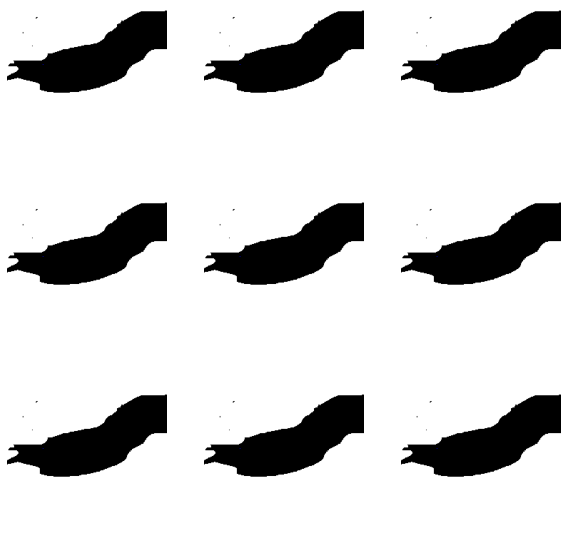

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[1].numpy().astype("uint8"))
    plt.axis("off")

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
normalization_layer = layers.Rescaling(1./255)

In [10]:
import numpy as np 
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image)) 

-0.003921569 0.003921569


In [11]:
base_model = MobileNetV2(weights='imagenet',include_top=False) #imports the mobilenet model and discards the last 1000 neuron layer.

base_model.trainable = False

x = base_model.output
x = data_augmentation(x)
x = Rescaling(1./255)(x)
x = GlobalAveragePooling2D()(x)
x = Dense(64,activation='relu')(x) #we add dense layers so that the model can learn more complex functions and classify for better results.
x = BatchNormalization()(x)
x = Dropout(rate=0.6)(x)
x = Dense(32,activation='relu')(x) #dense layer 2
x = Dense(16,activation='relu')(x) #dense layer 3

preds = Dense(1, activation='sigmoid')(x) #final layer with softmax activation

9420800/9406464 [==============================] - 0s 0us/step


In [12]:
model = Model(inputs=base_model.input,outputs=preds)

In [13]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 Conv1 (Conv2D)                 (None, None, None,   864         ['input_2[0][0]']                
                                32)                                                               
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, None, None,   128         ['Conv1[0][0]']                  
                                32)                                                           

In [14]:
len(model.layers)

163



In [15]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [16]:
opt = tf.optimizers.Adam(learning_rate=0.001)

In [17]:
model.compile(optimizer=opt , loss = 'binary_crossentropy' ,metrics=['acc'])

# Adam optimizer
# loss function will be categorical cross entropy
# evaluation metric will be accuracy

#step_size_train = train_generator.n // train_generator.batch_size

checkpointer = ModelCheckpoint(filepath ='mobilenet_V2_best',
                             monitor = 'val_acc',
                             verbose = 1,
                             save_best_only = True)

# class CustomCallback(tf.keras.callbacks.Callback):
#     def on_epoch_end(self, epoch, logs=None):
#         keys = list(logs.keys())
#         if(float(logs.get('val_acc')) > 0.92):
#             self.model.stop_training = True

# callbacks = tf.keras.callbacks.EarlyStopping(monitor='val_acc', patience=20)

history = model.fit_generator(generator = train_ds,
        validation_data = val_ds,
       epochs = 300 , shuffle = True , callbacks=[checkpointer])

Epoch 1/300


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:24: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.


 9/10 [==========================>...] - ETA: 0s - loss: 0.6718 - acc: 0.6111
Epoch 1: val_acc improved from -inf to 0.50000, saving model to mobilenet_V2_best
INFO:tensorflow:Assets written to: mobilenet_V2_best/assets
10/10 [==============================] - 48s 4s/step - loss: 0.6679 - acc: 0.6187 - val_loss: 0.6934 - val_acc: 0.5000
Epoch 2/300
 9/10 [==========================>...] - ETA: 0s - loss: 0.6214 - acc: 0.6111
Epoch 2: val_acc did not improve from 0.50000
10/10 [==============================] - 0s 41ms/step - loss: 0.6160 - acc: 0.6187 - val_loss: 0.6947 - val_acc: 0.5000
Epoch 3/300
 9/10 [==========================>...] - ETA: 0s - loss: 0.5742 - acc: 0.6319
Epoch 3: val_acc did not improve from 0.50000
10/10 [==============================] - 0s 35ms/step - loss: 0.5743 - acc: 0.6375 - val_loss: 0.6983 - val_acc: 0.5000
Epoch 4/300
10/10 [==============================] - ETA: 0s - loss: 0.5183 - acc: 0.6625
Epoch 4: val_acc did not improve from 0.50000
10/10 [======

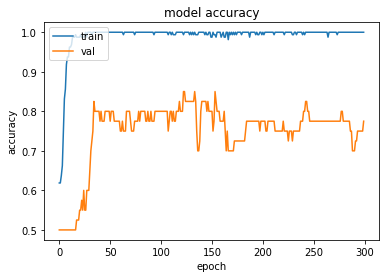

In [18]:
from matplotlib import pyplot as plt
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.savefig('model_accuracy_moblienets.png')
plt.show()


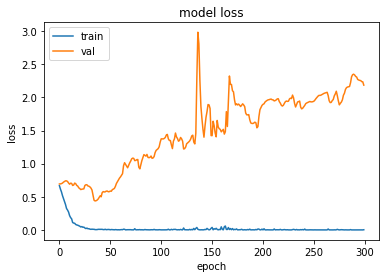

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.savefig('model_loss_moblienets.png')
plt.show()
